### **[전이학습 (transfer learning)]**
일반적으로 CNN 기반 DL 모델 훈련시키려면 많은 양의 데이터 필요. BUT 큰 데이터셋 얻는거 힘듦.

↓

SOL) **전이학습(transfer learning)**: 큰 데이터셋을 써서 훈련된 모델의 가중치를 가져와 우리가 해결하려는 과제에 맞게 보정해서 사용하는 것.

**  **사전 훈련된 모델(네트워크)**: 아주 큰 데이터셋을 사용하여 훈련된 모델.

---
전이 학습 방법 두 가지
1. **특성 추출 기법**
* ImageNet 데이터셋으로 사전 훈련된 모델을 가져온 후 마지막에 fc부분만 새로 만듦.
* 학습할 때는 마지막 완전연결층만 학습하고 나머지 계층들은 학습되지x.
* 특성 추출은 이미지 분류를 위해 두 부분으로 구성됨.
  * 합성곱층: 합성곱층과 풀링층으로 구성
  * 데이터 분류기(완전연결층): 추출된 특성을 입력받아 최종적으로 이미지에 대한 클래스를 분류하는 부분.
* 사전 훈련된 네트워크의 합성곱층에 새로운 데이터를 통과시키고, 그 출력을 데이터 분류기에서 훈련시킴.
* Xception, Inception V3, ResNet50, VGG16, VGG19, MobileNet

2. **미세 조정 기법**
* 사전 훈련된 모델과 합성곱층, 데이터 분류기의 가중치를 업데이트하여 훈련시키는 방법.
* 사전 학습된 모델을 목적에 맞게 재학습시키거나 학습된 가중치의 일부를 재학습시키는 것.
  * 데이터셋↑, 유사성↓ : 모델 전체 재학습.
  * 데이터셋↑, 유사성↑ : 합성곱층의 뒷부분(fc층과 가까운 부분)과 데이터 분류기를 학습시킴.
  * 데이터셋↓, 유사성↓ : 합성곱층의 일부분과 데이터 분류기 학습. (합성곱층 중 어디까지 새로 학습시켜야 할지 적당히 설정해야 함.)
  * 데이터셋↓, 유사성↑ : 데이터 분류기만 학습.

In [1]:
import os
import time
import copy
import glob
import cv2
import shutil

import torch
import torchvision # 컴퓨터 비전 용도의 패키지
import torchvision.transforms as transforms # 전처리 위해 사용되는 패키지
import torchvision.models as models # 다양한 파이토치 네트워크를 사용하게 하는 패키지
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
!git clone https://github.com/gilbutITbook/080289.git

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 2278 (delta 1), reused 0 (delta 0), pack-reused 2273 (from 2)
Receiving objects: 100% (2278/2278), 330.30 MiB | 27.24 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [4]:
data_path = './080289/chap05/data/catanddog/train/'

transform = transforms.Compose(
    [
        transforms.Resize([256,256]), # 256x256 크기로 이미지 데이터 조정.
        transforms.RandomResizedCrop(224), # 이미지를 랜덤한 크기 및 비율로 자름.
        transforms.RandomHorizontalFlip(), # 이미지를 랜덤하게 수평으로 뒤집음.
        transforms.ToTensor() # 이미지를 텐서로 변환.
    ]
) # 이미지 데이터를 변환하여 모델의 입력으로 사용할 수 있게 변환.
train_dataset = torchvision.datasets.ImageFolder(data_path, transform=transform)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8, # 데이터를 불러 올 때 하위 프로세스 몇 개 사용할지 설정.
    shuffle=True
)
print(len(train_dataset))

385


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


* torchvision.transfrom은 이미지 데이터를 변환하여 모델(네트워크)의 입력으로 시용할 수 있게 변환.
  * Resize: 이미지의 크기를조정. 즉 256 x256 크기로 이미지 데이터를조정.
  * RandomResizedCrop: 이미지를 랜덤한 크기 및 비율로 자름.
  * RandomHorizontalFlip: 이미지를 랜덤하게 수평으로 뒤집음.
  * ToTensor: 이미지 데이터를 텐서로 변환.
* datasets.lmageFolder는 데이터로더가 데이터를 불러올 대상(혹은 경로)과 방법(transform)(혹은 전처리)을 정의.
* train_loader: 데이터로더는 데이터를 불러오는 부분으로 앞에서 정의한 ImageFolder(train_dataset)을 데이터로더에 할당하는데， 이때 한 번에 불러올 데이터양을 결정하는 batch size를 지정합니다. 또한， 추가적으로 데이터를 무작위로 섞을(shuff1e) 것인지도 설정.
  *  batch_size: 한 번에 불러올 데이터OJ을 결정히는 배치 크기를 설정.
  * num_workers: 데이터를 불러올 때 하위 프로세스를 몇 개 사용할지 설정하는데， 이때 너무 많은 하위 프로세스를 설정하게 되면 오류가 발생하거나 메모리 부족 현상이 발생.
  * shuffle: 데이터를 무작위로 섞을지를 지정.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


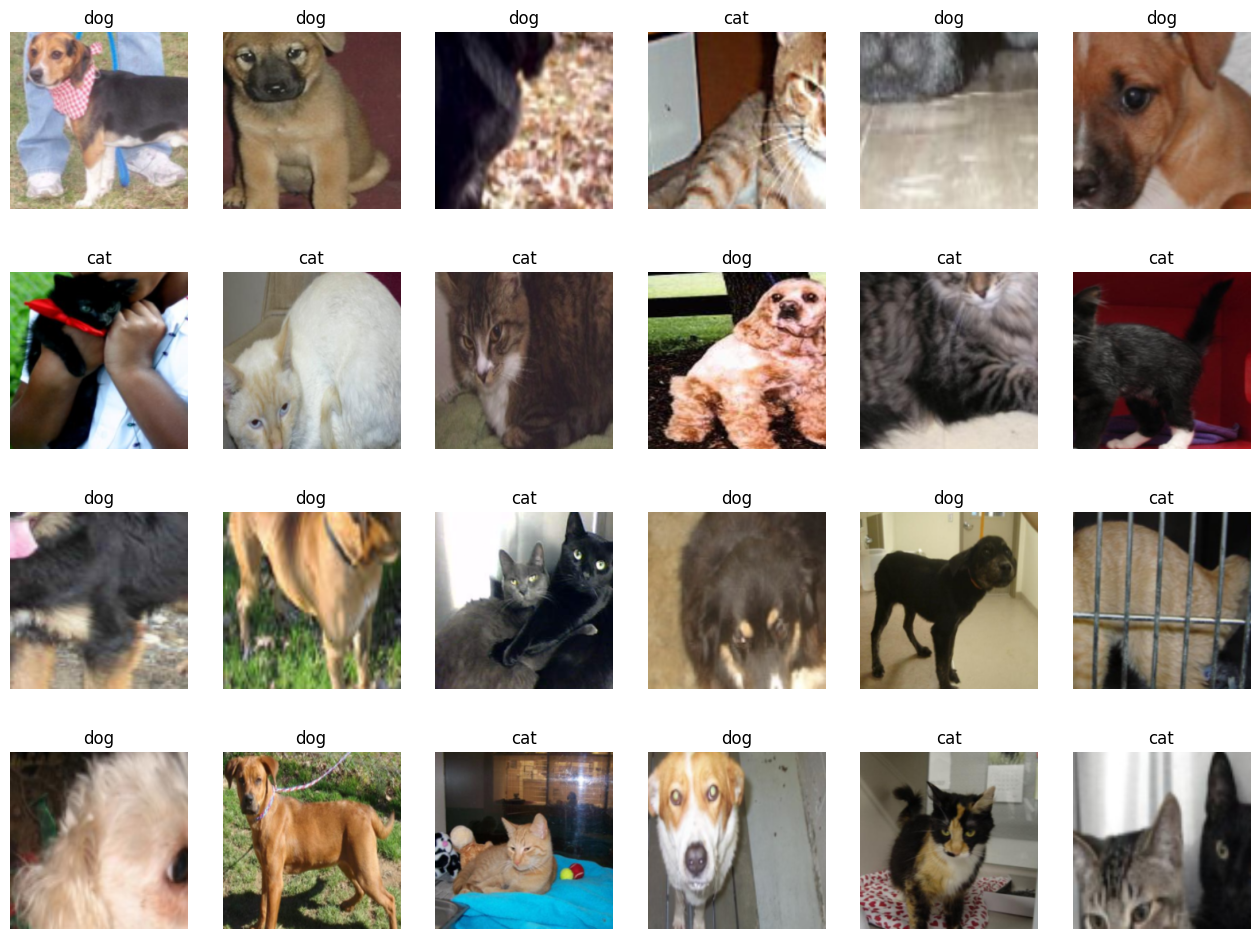

In [5]:
# 학습에 사용될 이미지 출력
import numpy as np

samples, labels = next(iter(train_loader)) # 반복자 사용하려면 iter와 next 필요.
classes = {0:'cat', 1:'dog'}
fig = plt.figure(figsize=(16,24))
for i in range(24):
  a = fig.add_subplot(4, 6, i+1)
  a.set_title(classes[labels[i].item()]) # 레이블 정보를 함께 출력
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(), (1,2,0)))
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

* 반복자(i terator. for 구문과 같은 효과)를 사용하려면 iter()와 next()가 필요. iter( )는 전달된 데이터의 반복자를 꺼내 반환하며 next()는 그 반복자가 다음에 출력해야 할 요소를 반환.
*  np. transpose는 다음 그림과 같이 행과 열을 비꿈으로써 행렬의 차원을 바꾸어 줌. 일반적으로 행렬의 차원을 변경하는 이유는 행렬의 내적 연산 때문.

In [6]:
resnet18 = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 68.4MB/s]


In [7]:
# 사전 훈련된 모델의 파라미터 학습 유무 지정
def set_parameter_requires_grad(model, feature_extracting=True):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False  # 역전파 중 파라미터들에 대한 변화 계산할 필요 없음.
set_parameter_requires_grad(resnet18)

In [8]:
# ResNet18에 fc 추가
resnet18.fc = nn.Linear(512,2) # 2는 클래스가 두 개라는 의미

In [9]:
# 모델의 파라미터 값들 확인
for name, param in resnet18.named_parameters():
  if param.requires_grad:
    print(name, param.data)

fc.weight tensor([[ 0.0195, -0.0231,  0.0306,  ...,  0.0289, -0.0071,  0.0395],
        [ 0.0180,  0.0021, -0.0366,  ...,  0.0401, -0.0180, -0.0067]])
fc.bias tensor([0.0008, 0.0347])


In [10]:
# 모델 객체 생성 및 손실 함수 정의
model = models.resnet18(pretrained = True)

for param in model.parameters():
    param.requires_grad = False

model.fc = torch.nn.Linear(512, 2)
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss()
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
# 모델 학습을 위한 함수 생성
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
    since = time.time()
    acc_history = []
    loss_history = []
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders:
            inputs = inputs.to(device)
            labels = labels.to(device)

            model.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloaders.dataset)
        epoch_acc = running_corrects.double() / len(dataloaders.dataset)

        print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        loss_history.append(epoch_loss)
        torch.save(model.state_dict(), os.path.join('./080289/chap05/data/catanddog/', '{0:0=2d}.pth'.format(epoch)))
        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:4f}'.format(best_acc))
    return acc_history, loss_history

In [12]:
# 파라미터 학습 결과를 옵티마이저에 전달
params_to_update = []
for name, param in resnet18.named_parameters():
  if param.requires_grad == True:
    params_to_update.append(param)
    print('\t', name)

optimizer = optim.Adam(params_to_update)

	 fc.weight
	 fc.bias


In [13]:
# 모델 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------
Loss: 0.5748 Acc: 0.6909

Epoch 1/12
----------
Loss: 0.3943 Acc: 0.8286

Epoch 2/12
----------
Loss: 0.3108 Acc: 0.8883

Epoch 3/12
----------
Loss: 0.2889 Acc: 0.8883

Epoch 4/12
----------
Loss: 0.2607 Acc: 0.8961

Epoch 5/12
----------
Loss: 0.2214 Acc: 0.9247

Epoch 6/12
----------
Loss: 0.2575 Acc: 0.8805

Epoch 7/12
----------
Loss: 0.2801 Acc: 0.8909

Epoch 8/12
----------
Loss: 0.2794 Acc: 0.8779

Epoch 9/12
----------
Loss: 0.2948 Acc: 0.8597

Epoch 10/12
----------
Loss: 0.1951 Acc: 0.9221

Epoch 11/12
----------
Loss: 0.1846 Acc: 0.9117

Epoch 12/12
----------
Loss: 0.1635 Acc: 0.9351

Training complete in 9m 59s
Best Acc: 0.935065


약93%로 상당히 높은 정확도를보여 주고 있습니다. 훈련 데이터로는학습이 잘되었다고 할 수 있다. 이제 태스트 용도의 데이터를 이용하여 모델 정확도를 측정해 보아야 한다.

In [14]:
# 테스트 데이터 호출 및 전처리
test_path = './080289/chap05/data/catanddog/test/'

transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
    ])
test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)
print(len(test_dataset))

98


In [15]:
# 테스트 데이터 평가 함수 생성
def eval_model(model, dataloaders, device):
  since = time.time()
  acc_history = []
  best_acc = 0.0

  saved_models = glob.glob('./080289/chap05/data/catanddog/' + '*.pth')
  saved_models.sort()
  print('saved_model', saved_models)

  for model_path in saved_models:
    print('Loading model', model_path)

    model.load_state_dict(torch.load(model_path))
    model.eval()
    model.to(device)
    running_corrects = 0

    for inputs, labels in dataloaders:
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.no_grad():
        outputs = model(inputs)

      _, preds = torch.max(outputs.data, 1)
      preds[preds >= 0.5] = 1
      preds[preds < 0.5] = 0
      running_corrects += preds.eq(labels).int().sum()

    epoch_acc = running_corrects.double() / len(dataloaders.dataset)
    print('Acc: {:.4f}'.format(epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    print()

  time_elapsed = time.time() - since
  print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))

  return acc_history

*  glob은현재 디렉터리에서 원하는 파일들만 추출하여 가져올 때 사용합니다. 즉， ‘ . ./chap05/
data/ catanddog/’ 경로에서 pth 확장자를 갖는 파일을 가져오라는 의미. pth라는 확장자
를 갖는 파일은 훈련 데이터로 모댈을 훈련시킬 때 생성된 파일.
*  torch.max는 주어진 텐서 배열의 최댓값이 들어 있는 index를 반환하는 함수.
*  preds.eq(labels)는 preds 배열과 labels가 일치하는지 검사히는 용도로 사용.뒤에 사용된 .sum()은 모델의 예측 결과와 정답(레이블)이 일치히는 것들의 개수 합을 숫자로 출력.

In [16]:
# 테스트 데이터를 평가 함수에 적용
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['./080289/chap05/data/catanddog/00.pth', './080289/chap05/data/catanddog/01.pth', './080289/chap05/data/catanddog/02.pth', './080289/chap05/data/catanddog/03.pth', './080289/chap05/data/catanddog/04.pth', './080289/chap05/data/catanddog/05.pth', './080289/chap05/data/catanddog/06.pth', './080289/chap05/data/catanddog/07.pth', './080289/chap05/data/catanddog/08.pth', './080289/chap05/data/catanddog/09.pth', './080289/chap05/data/catanddog/10.pth', './080289/chap05/data/catanddog/11.pth', './080289/chap05/data/catanddog/12.pth']
Loading model ./080289/chap05/data/catanddog/00.pth
Acc: 0.8776

Loading model ./080289/chap05/data/catanddog/01.pth
Acc: 0.9490

Loading model ./080289/chap05/data/catanddog/02.pth
Acc: 0.9490

Loading model ./080289/chap05/data/catanddog/03.pth
Acc: 0.9388

Loading model ./080289/chap05/data/catanddog/04.pth
Acc: 0.9592

Loading model ./080289/chap05/data/catanddog/05.pth
Acc: 0.9490

Loading model ./080289/chap05/data/catanddog/06.pth
Acc: 0.9388


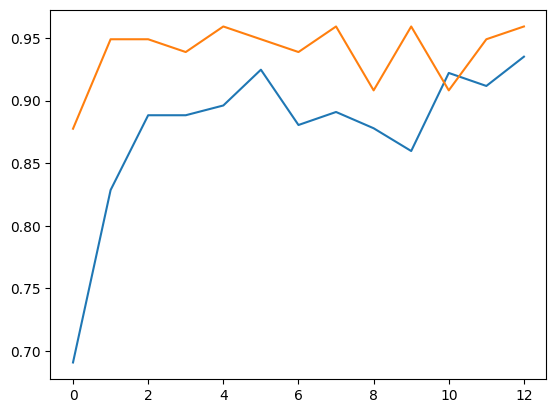

In [17]:
# 훈련과 테스트 데이터의 정확도를 그래프로 확인
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

다음 그림은 훈련과 테스트 데이터에 대해 에포크가 진행될 때마다 정확도를 출력한 결과.
훈련과 테스트 데이터 모두 에포크가 진행될수록 정확도가 높아지면서 100% 가까워지고 있다. 실제로 더 많은 에포크를 진행한다면 더욱더 100%에 수렴하는 것을 확인할 수 있다.

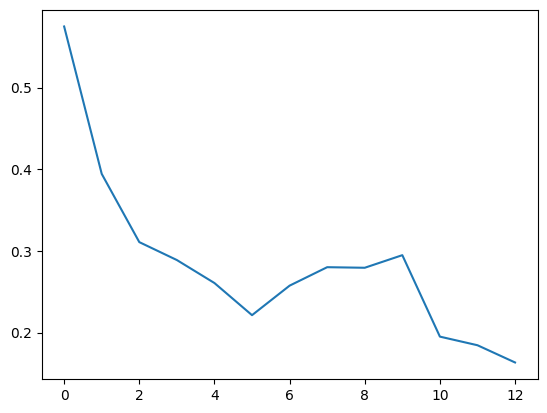

In [18]:
# 훈련 데이터의 오차에 대한 그래프 확인
plt.plot(train_loss_hist)
plt.show()

In [19]:
# 예측 이미지 출력을 위한 전처리 함수
def im_convert(tensor):
  image = tensor.clone().detach().numpy() # clone은 기존 텐서의 내용을 복사한 텐서 생성. detach는 기존 텐서에서 기울기가 전파되지 않는 텐서.
  image = image.transpose(1,2,0)
  image = image * (np.array((0.5,0.5,0.5)))
  image = image.clip(0,1) # 입력 값이 주어진 범위를 벗어날 때 입력 값을 특정 범위로 제한시키기 위해 사용. 즉 clip(0,1)은 image 데이터를 0과 1 사이의 값으로 제한.
  return image

* tensor. clone ()은 기존 댄서의 내용을 복사한 텐서를 생성하겠다는 의미이며， detach()는 기존 텐서에서 기울기가 전파되지 않는 텐서.  즉 tensor.clone().detach()는 기존 텐서를
복사한 새로운 텐서를 생성하지만 기울기에 영향을 주지는 않겠다는 의미.

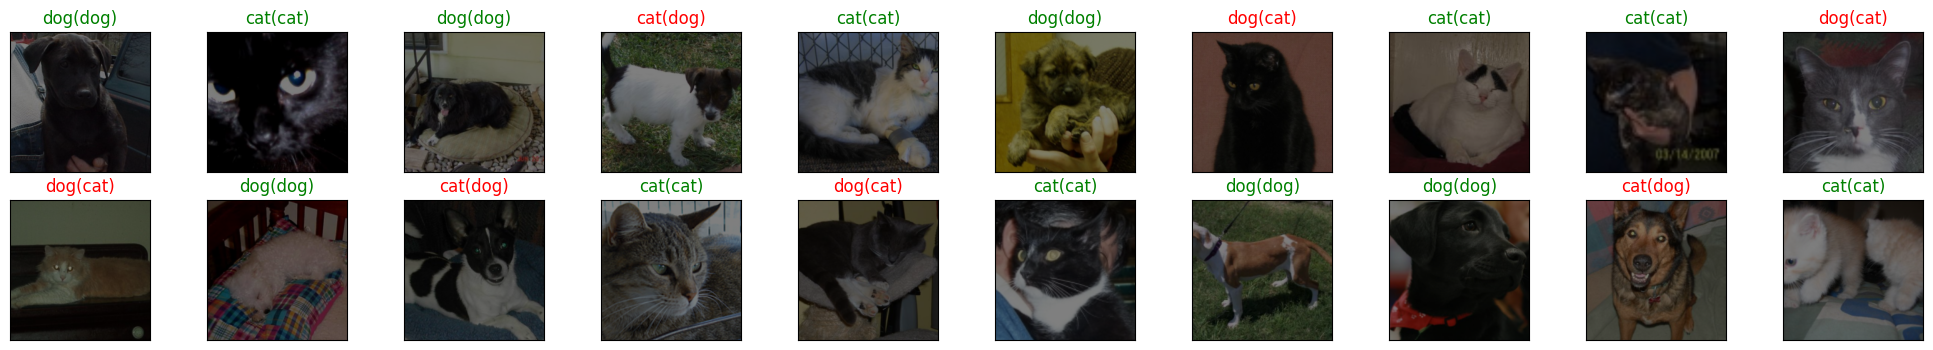

<Figure size 640x480 with 0 Axes>

In [20]:
# 개와 고양이 예측 결과 출력
classes = {0:'cat', 1:'dog'}

dataiter = iter(test_loader) # 테스트 데이터셋을 가져옴
images, labels = next(dataiter)
output = model(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25,4))
for idx in np.arange(20):
  ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[]) # 2행 10열. tick삭제하겠다~
  plt.imshow(im_convert(images[idx]))
  a.set_title(classes[labels[i].item()]) # 0과 1 중 어떤 값을 갖는지 판별하겠다.
  ax.set_title('{}({})'.format(str(classes[preds[idx].item()]), str(classes[labels[idx].item()])), color=('green' if preds[idx]==labels[idx] else 'red'))
plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

* add_subplot은 한 화면에 여러 개의 이미지를 담기 위해 사용
  * 첫 번째 파라미터: 행의 수를 의미하는데 이미지를 두 줄로 출력.
  * 두 번째 파라미터 : 열의 수를 의미하는데， 한 줄에 열 개의 이미지를 출력.
  * 세 번째 파라미터 : 인텍스를 의미하는데 행과 열을 기준으로 순차적으로 이미지를 출력.
  * 네 번째 파라미터 : 틱(tick)을 삭제하겠다는 의미.
* classes[preds[idx].item()]은 preds[idx].item() 값이 classes로 정의된 ‘0’과 ‘1’ 중 어떤 값을 갖는지 판별하겠다는 의미입니다. 즉， classes[preds[idx].item()] 값이 0이면 고양이, 1 이면 개로 출력됨.
*  left, bottom, right, top으로 이미지 위치를 조정합니다. 또한， hspace와
wspace를 사용해서 서브플롯 간의 간격(너비와 높이의 비율)을 조정.